In [20]:
import torch
import numpy as np
import sys
import omnilearned
sys.path.append("/home/yfkahn/projects/aip-yfkahn/shared/jet_interpretability_diffusion/GenerativeModelsOnPhaseSpace-main")
from omnilearn_lightning import qspace
import matplotlib.pyplot as plt
from energyflow import EFP
from energyflow import EFPSet

import itertools
from itertools import combinations
from scipy.optimize import minimize

In [21]:
def ThreeVecToFourVec(p3):
    E = torch.linalg.norm(p3,dim=-1,keepdim=True)
    p4 = torch.cat([E,p3],dim=-1)
    return np.array(p4)

def min_pairwise_dot(p4):                                                                                                                               
    """Min of E_i*E_j - p⃗_i·p⃗_j over all pairs, shape (NEvents,)."""                                                                                    
    E = p4[:, :, 0]                                          # (N, P)                                                                                   
    EiEj = E[:, :, None] * E[:, None, :]                     # (N, P, P)
    p3 = p4[:, :, 1:]
    dots = np.einsum('bid,bjd->bij', p3, p3)  # (N, P, P)                                                                           
    pipj = EiEj - dots                                       # (N, P, P)
    # Mask diagonal (self-pairs) with inf
    pipj[:, range(p4.shape[1]), range(p4.shape[1])] = float('inf')
    return pipj.min(axis=-1).min(axis=-1)         # (N,)

def make_mindot_hist(Pdat,Nbins=50,log=True):
    Ps = Pdat
    p4s = ThreeVecToFourVec(Ps)
    mindots = min_pairwise_dot(p4s)
    if log:
        mindots_hist, bins = np.histogram(np.log10(mindots),bins=Nbins,density=True)
    else:
        mindots_hist, bins = np.histogram(mindots,bins=Nbins,density=True)
    return mindots_hist, bins 

def Ldot(p1,p2,R=1,beta=1): #just the Lorentz dot product
    E1, E2 = p1.norm(dim=-1), p2.norm(dim=-1)
    dot = (p1 * p2).sum(dim=-1)
    return E1*E2 - dot

# checks to make sure model is good (can skip this section)

In [65]:
qhead="forward_backward_outputs/N18_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
ts_forward = [100, 200, 300, 400, 500, 600, 700]
#qhead="/home/yfkahn/projects/aip-yfkahn/shared/jet_interpretability_diffusion/forward_backward_outputs_harry/nparticles=10/qspace_small_ism_N10_T5000_ee2qqbar_S2000GeV_a0p1365_N1p9M_tgaus0k~1-4999_fine_rough_steps=10_10_ntraj=128_nevents=256_T"
#ts_forward = [100, 200]#, 300, 400, 500, 600, 700, 800, 900]
phats = []
for i in ts_forward:
    qhats = torch.load(qhead+str(i)+".pt")
#    qhats = torch.load(qhead+str(i)).to(dtype=torch.float64)
    ps_temp = torch.zeros(qhats.shape)
    for j in range(ps_temp.shape[0]):
        ps_temp[j]=qspace.qs_to_ps(qhats[j])
    phats.append(ps_temp) #shape (checkpoints, trajectories, samples, particles, 3-momentum)

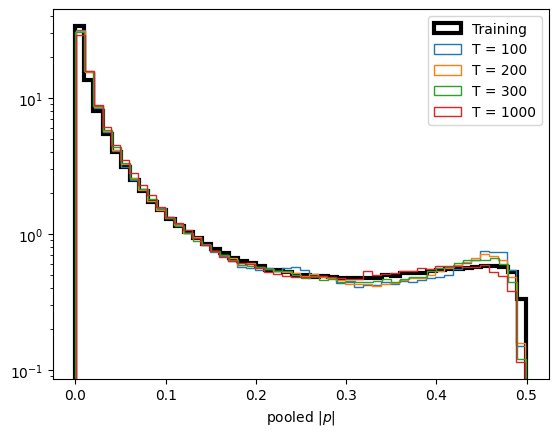

/tmp/ipykernel_1908414/2581210306.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


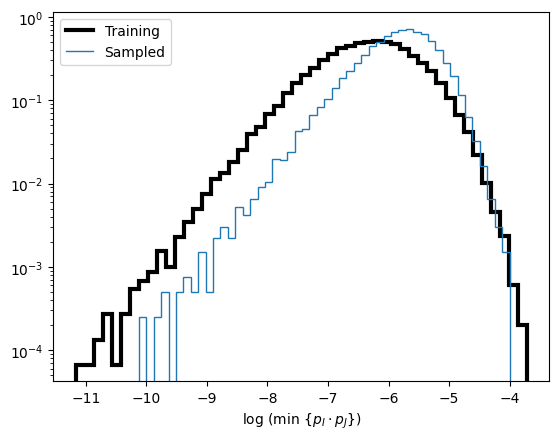

In [43]:
#to make sure there is no issue with permutations, load the q-space data which was used as a starting point for the round-trip files, then convert to p-space
qspace_dat = torch.load("/home/yfkahn/scratch/q_space_datasets/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=10_Nparticles=12_p3_normalized_T5000_tgaus0_fluff1/Q0.pt")
pspace_dat = qspace.qs_to_ps(qspace_dat)
ntraj, nsample, nparticles = phats[0].shape[0], phats[0].shape[1], phats[0].shape[2]

#all of these distributions are fully denoised, and so should look like the training data

plt.hist(pspace_dat[:100000].norm(dim=-1).flatten(),bins=50,histtype='step',color='k',lw=3,density=True,label='Training')
plt.hist(phats[0].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label=f"T = {ts_forward[0]}")
plt.hist(phats[1].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label=f"T = {ts_forward[1]}")
plt.hist(phats[2].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label=f"T = {ts_forward[2]}")
plt.hist(phats[-1].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label=f"T = {ts_forward[-1]}")
plt.yscale('log')
plt.xlabel(r'pooled $|p|$')
plt.legend()
plt.show()

mindots_true_hist, mindot_bins_true = make_mindot_hist(pspace_dat[:100000].to(torch.float64))
mindots_gen_hist, mindot_bins_gen = make_mindot_hist(phats[-1].reshape((ntraj*nsample,nparticles,3)).to(torch.float64))
plt.stairs(mindots_true_hist, mindot_bins_true,color='k',lw=3,label='Training')
plt.stairs(mindots_gen_hist, mindot_bins_gen,label='Sampled')
plt.yscale('log')
plt.xlabel(r'log (min $\{p_I \cdot p_J\}$)')
plt.legend(loc='upper left')
plt.show()


# load the data

In [22]:
def make_phats(qhead,ts_forward):
    phats = []
    for i in ts_forward:
        qhats = torch.load(qhead+str(i)+".pt")
        ps_temp = torch.zeros(qhats.shape)
        for j in range(ps_temp.shape[0]):
            ps_temp[j]=qspace.qs_to_ps(qhats[j])
        phats.append(ps_temp) #shape (checkpoints, trajectories, samples, particles, 3-momentum)
    return phats

In [23]:
qhead_10="forward_backward_outputs/N10_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
ts_forward_10 = [50, 100, 150, 200, 250, 300, 350, 400, 450, 550, 600, 650, 750, 800, 1000, 1200, 1400, 1600, 1800, 2000]
pspace_dat_10 = torch.load("/home/yfkahn/projects/aip-yfkahn/shared/intermediate_by_nbranch/ee2qqbar/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=8_Nparticles=10_p3_normalized.pt")
phats_10 = make_phats(qhead_10,ts_forward_10)

qhead_12="forward_backward_outputs/N12_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
ts_forward_12 = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 2000, 2500, 3000]
qspace_dat_12 = torch.load("/home/yfkahn/scratch/q_space_datasets/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=10_Nparticles=12_p3_normalized_T5000_tgaus0_fluff1/Q0.pt")
pspace_dat_12 = qspace.qs_to_ps(qspace_dat_12)
phats_12 = make_phats(qhead_12,ts_forward_12)

qhead_14="forward_backward_outputs/N14_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
ts_forward_14 = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000]
qspace_dat_14 = torch.load("/home/yfkahn/scratch/q_space_datasets/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=12_Nparticles=14_p3_normalized_T5000_tgaus0_fluff1/Q0.pt")
pspace_dat_14 = qspace.qs_to_ps(qspace_dat_14)
phats_14 = make_phats(qhead_14,ts_forward_14)

qhead_16="forward_backward_outputs/N16_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
ts_forward_16 = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000]
qspace_dat_16 = torch.load("/home/yfkahn/scratch/q_space_datasets/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=14_Nparticles=16_p3_normalized_T5000_tgaus0_fluff1/Q0.pt")
pspace_dat_16 = qspace.qs_to_ps(qspace_dat_16)
phats_16 = make_phats(qhead_16,ts_forward_16)

qhead_18="forward_backward_outputs/N18_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
ts_forward_18 = [50, 100, 200, 300, 500, 600, 800, 900, 1000, 1500, 2000, 2500, 3000]
qspace_dat_18 = torch.load("/home/yfkahn/scratch/q_space_datasets/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=16_Nparticles=18_p3_normalized_T5000_tgaus0_fluff1/Q0.pt")
pspace_dat_18 = qspace.qs_to_ps(qspace_dat_18)
phats_18 = make_phats(qhead_18,ts_forward_18)

qhead_20="forward_backward_outputs/N20_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
ts_forward_20 = [50, 100, 200, 300, 400, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 2000, 2500, 3000]
qspace_dat_20 = torch.load("/home/yfkahn/scratch/q_space_datasets/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=18_Nparticles=20_p3_normalized_T5000_tgaus0_fluff1/Q0.pt")
pspace_dat_20 = qspace.qs_to_ps(qspace_dat_20)
phats_20 = make_phats(qhead_20,ts_forward_20)

# Compute (naive) momentum susceptibility -- we probably don't want to use this

In [16]:
def compute_momentum_susceptibility(p0,phat,norm=True): #computes at fixed time: phats is a (Ntraj,Nsample,Nparticles,3) array
    Ntraj=phat.shape[0]
    Nsample=phat.shape[1]
    DeltaPs = p0[None,:Nsample,...]-phat
    pnorms=DeltaPs.norm(dim=-1)
    Cij_trajavg=(1/pnorms.shape[0])*torch.einsum('tnp,tnq->npq',pnorms,pnorms)- torch.einsum('np,nq->npq',pnorms.mean(dim=0),pnorms.mean(dim=0))
    Cij=Cij_trajavg.mean(dim=0)
    if norm:
        chi=torch.sum(Cij)/torch.sum(Cij.diag())
    else:
        chi=torch.sum(Cij)
    return chi

In [17]:
chis_norm_10=[]
chis_norm_12=[]
chis_norm_14=[]
chis_norm_16=[]
chis_norm_18=[]
chis_norm_20=[]

for i in range(len(ts_forward_10)):
    chi = compute_momentum_susceptibility(pspace_dat_10,phats_10[i])
    chis_norm_10.append(chi)

for i in range(len(ts_forward_12)):
    chi = compute_momentum_susceptibility(pspace_dat_12,phats_12[i])
    chis_norm_12.append(chi)

for i in range(len(ts_forward_14)):
    chi = compute_momentum_susceptibility(pspace_dat_14,phats_14[i])
    chis_norm_14.append(chi)

for i in range(len(ts_forward_16)):
    chi = compute_momentum_susceptibility(pspace_dat_16,phats_16[i])
    chis_norm_16.append(chi)

for i in range(len(ts_forward_18)):
    chi = compute_momentum_susceptibility(pspace_dat_18,phats_18[i])
    chis_norm_18.append(chi)

for i in range(len(ts_forward_20)):
    chi = compute_momentum_susceptibility(pspace_dat_20,phats_20[i])
    chis_norm_20.append(chi)

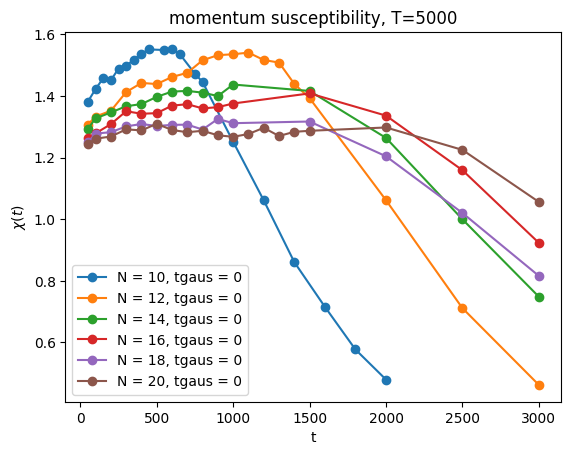

In [20]:
plt.plot(ts_forward_10,chis_norm_10,'o-',label='N = 10, tgaus = 0')
plt.plot(ts_forward_12,chis_norm_12,'o-',label='N = 12, tgaus = 0')
plt.plot(ts_forward_14,chis_norm_14,'o-',label='N = 14, tgaus = 0')
plt.plot(ts_forward_16,chis_norm_16,'o-',label='N = 16, tgaus = 0')
plt.plot(ts_forward_18,chis_norm_18,'o-',label='N = 18, tgaus = 0')
plt.plot(ts_forward_20,chis_norm_20,'o-',label='N = 20, tgaus = 0')

plt.title('momentum susceptibility, T=5000')
plt.xlabel('t')
plt.ylabel(r'$\chi(t)$')
plt.legend(loc='lower left')



# momentum susceptibility, but using EMD or dot product

In [25]:
#NOTE: Claude thinks "max" in (7.2) of https://arxiv.org/pdf/2305.03751 is a typo, should be min
# hence the two different definitions of EMD

def EMD_max(p1,p2,R=1,beta=1):
    E1, E2 = p1.norm(dim=-1), p2.norm(dim=-1)
    dot = (p1 * p2).sum(dim=-1)
    cross_norm = torch.linalg.cross(p1, p2, dim=-1).norm(dim=-1)
    thetas = torch.atan2(cross_norm, dot)
    return torch.max(E1,E2)*(thetas/R)**beta + torch.abs(E1-E2)

def EMD_min(p1,p2,R=1,beta=1): #single-particle EMD, analytically
    E1, E2 = p1.norm(dim=-1), p2.norm(dim=-1)
    dot = (p1 * p2).sum(dim=-1)
    cross_norm = torch.linalg.cross(p1, p2, dim=-1).norm(dim=-1)
    thetas = torch.atan2(cross_norm, dot)
    return torch.min(E1,E2)*(thetas/R)**beta + torch.abs(E1-E2) 

In [26]:
def compute_EMD_susceptibility(p0,phat,beta=1,norm=True,use_max=False,use_dot=False): #computes at fixed time: phats is a (Ntraj,Nsample,Nparticles,3) array
    Ntraj=phat.shape[0]
    Nsample=phat.shape[1]
    if use_max:
        EMDs=EMD_max(p0[None,:Nsample,...],phat,beta=beta)
    elif use_dot:
        EMDs=Ldot(p0[None,:Nsample,...],phat,beta=beta)
    else:
        EMDs=EMD_min(p0[None,:Nsample,...],phat,beta=beta)
    Cij_trajavg=(1/EMDs.shape[0])*torch.einsum('tnp,tnq->npq',EMDs,EMDs)- torch.einsum('np,nq->npq',EMDs.mean(dim=0),EMDs.mean(dim=0))
    Cij=Cij_trajavg.mean(dim=0)
    if norm:
        chi=torch.sum(Cij)/torch.sum(Cij.diag())
    else:
        chi=torch.sum(Cij)
    return chi

In [27]:
chis_EMD_min_10=[]
chis_EMD_max_10=[]
chis_EMD_dot_10=[]
for i in range(len(ts_forward_10)):
    chi = compute_EMD_susceptibility(pspace_dat_10,phats_10[i],beta=2)
    chis_EMD_min_10.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_10,phats_10[i],use_max=True)
    chis_EMD_max_10.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_10,phats_10[i],use_dot=True)
    chis_EMD_dot_10.append(chi)

chis_EMD_min_12=[]
chis_EMD_max_12=[]
chis_EMD_dot_12=[]
for i in range(len(ts_forward_12)):
    chi = compute_EMD_susceptibility(pspace_dat_12,phats_12[i],beta=2)
    chis_EMD_min_12.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_12,phats_12[i],use_max=True)
    chis_EMD_max_12.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_12,phats_12[i],use_dot=True)
    chis_EMD_dot_12.append(chi)

chis_EMD_min_14=[]
chis_EMD_max_14=[]
chis_EMD_dot_14=[]
for i in range(len(ts_forward_14)):
    chi = compute_EMD_susceptibility(pspace_dat_14,phats_14[i],beta=2)
    chis_EMD_min_14.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_14,phats_14[i],use_max=True)
    chis_EMD_max_14.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_14,phats_14[i],use_dot=True)
    chis_EMD_dot_14.append(chi)

chis_EMD_min_16=[]
chis_EMD_max_16=[]
chis_EMD_dot_16=[]
for i in range(len(ts_forward_16)):
    chi = compute_EMD_susceptibility(pspace_dat_16,phats_16[i],beta=2)
    chis_EMD_min_16.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_16,phats_16[i],use_max=True)
    chis_EMD_max_16.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_16,phats_16[i],use_dot=True)
    chis_EMD_dot_16.append(chi)

chis_EMD_min_18=[]
chis_EMD_max_18=[]
chis_EMD_dot_18=[]
for i in range(len(ts_forward_18)):
    chi = compute_EMD_susceptibility(pspace_dat_18,phats_18[i],beta=2)
    chis_EMD_min_18.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_18,phats_18[i],use_max=True)
    chis_EMD_max_18.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_18,phats_18[i],use_dot=True)
    chis_EMD_dot_18.append(chi)

chis_EMD_min_20=[]
chis_EMD_max_20=[]
chis_EMD_dot_20=[]
for i in range(len(ts_forward_20)):
    chi = compute_EMD_susceptibility(pspace_dat_20,phats_20[i],beta=2)
    chis_EMD_min_20.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_20,phats_20[i],use_max=True)
    chis_EMD_max_20.append(chi)
    chi = compute_EMD_susceptibility(pspace_dat_20,phats_20[i],use_dot=True)
    chis_EMD_dot_20.append(chi)

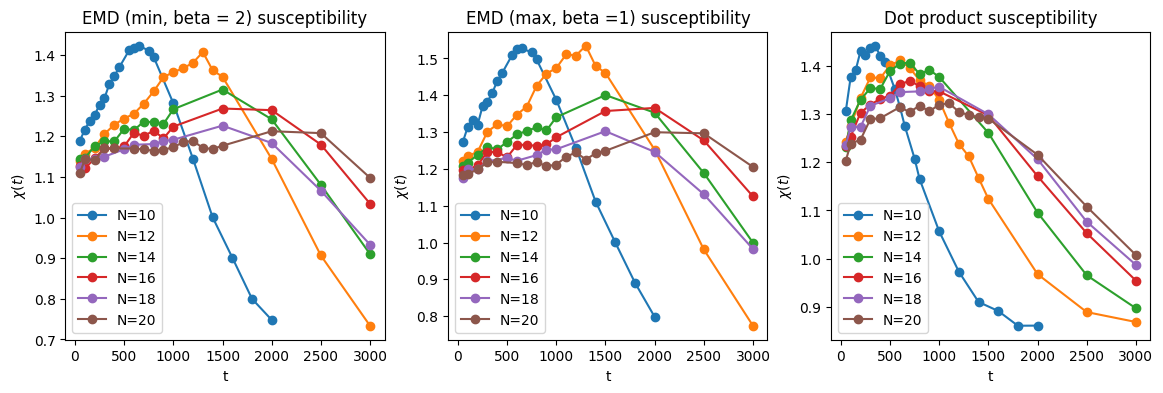

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(ts_forward_10,chis_EMD_min_10,'o-',label='N=10')
axes[0].plot(ts_forward_12,chis_EMD_min_12,'o-',label='N=12')
axes[0].plot(ts_forward_14,chis_EMD_min_14,'o-',label='N=14')
axes[0].plot(ts_forward_16,chis_EMD_min_16,'o-',label='N=16')
axes[0].plot(ts_forward_18,chis_EMD_min_18,'o-',label='N=18')
axes[0].plot(ts_forward_20,chis_EMD_min_20,'o-',label='N=20')
axes[0].set_title('EMD (min, beta = 2) susceptibility')

axes[1].plot(ts_forward_10,chis_EMD_max_10,'o-',label='N=10')
axes[1].plot(ts_forward_12,chis_EMD_max_12,'o-',label='N=12')
axes[1].plot(ts_forward_14,chis_EMD_max_14,'o-',label='N=14')
axes[1].plot(ts_forward_16,chis_EMD_max_16,'o-',label='N=16')
axes[1].plot(ts_forward_18,chis_EMD_max_18,'o-',label='N=18')
axes[1].plot(ts_forward_20,chis_EMD_max_20,'o-',label='N=20')
axes[1].set_title('EMD (max, beta =1) susceptibility')

axes[2].plot(ts_forward_10,chis_EMD_dot_10,'o-',label='N=10')
axes[2].plot(ts_forward_12,chis_EMD_dot_12,'o-',label='N=12')
axes[2].plot(ts_forward_14,chis_EMD_dot_14,'o-',label='N=14')
axes[2].plot(ts_forward_16,chis_EMD_dot_16,'o-',label='N=16')
axes[2].plot(ts_forward_18,chis_EMD_dot_18,'o-',label='N=18')
axes[2].plot(ts_forward_20,chis_EMD_dot_20,'o-',label='N=20')
axes[2].set_title('Dot product susceptibility')

for i in range(3):
    axes[i].set_xlabel('t')
    axes[i].set_ylabel(r'$\chi(t)$')
    axes[i].legend(loc='lower left')

# thrust susceptibility

In [29]:
def _sign_matrix(L, device, dtype):
    """All 2^(L-1) sign vectors of length L, first entry fixed to +1
    (eps and -eps give the same |sum_i eps_i p_i|, so half suffice)."""
    rows = [(1,) + tail for tail in itertools.product((1, -1), repeat=L - 1)]
    return torch.tensor(rows, device=device, dtype=dtype)

@torch.no_grad()
def compute_thrust_axis_torch(events, device='cuda', dtype=torch.float64,
                              chunk=20000, max_enum=16, n_seed=10, n_iter=20,
                              return_thrust=False):
    """Exact thrust axis (and optionally thrust) for a batch of e+e- events.
    events: (..., M, 4) = (E, px, py, pz), with any number of leading batch
    dimensions (including none).
    Returns axis (..., 3) numpy, or (axis, thrust) if return_thrust.
    """
    ev = torch.as_tensor(events, dtype=dtype)
    batch_shape, M = ev.shape[:-2], ev.shape[-2]
    ev = ev.reshape(-1, *ev.shape[-2:])
    B = ev.shape[0]
    ax_out = torch.empty(B, 3, dtype=dtype)
    t_out = torch.empty(B, dtype=dtype)

    def _finish(sums, denom):                       # sums: (b, K, 3)
        best = sums.norm(dim=-1).max(dim=1)         # values, indices
        axis = torch.gather(sums, 1,
                            best.indices[:, None, None].expand(-1, 1, 3)).squeeze(1)
        axis = axis / best.values.unsqueeze(-1).clamp_min(1e-30)
        # sign convention: n_z > 0, tie-broken by n_y then n_x
#        key = torch.where(axis[:, 2] != 0, axis[:, 2],
#              torch.where(axis[:, 1] != 0, axis[:, 1], axis[:, 0]))
#        axis = axis * torch.where(key < 0, -1.0, 1.0).to(dtype).unsqueeze(-1)
        return axis, best.values / denom

    if M <= max_enum:                               # exact enumeration
        S = _sign_matrix(M, device, dtype)          # (K, M), K = 2^(M-1)
        for s in range(0, B, chunk):
            p = ev[s:s+chunk, :, 1:4].to(device)
            denom = p.norm(dim=-1).sum(dim=-1)
            sums = torch.einsum('km,bmd->bkd', S, p)
            axis, T = _finish(sums, denom)
            ax_out[s:s+chunk], t_out[s:s+chunk] = axis.cpu(), T.cpu()
    else:                                           # seeded fixed-point fallback
        S = _sign_matrix(n_seed, device, dtype)
        for s in range(0, B, chunk):
            p = ev[s:s+chunk, :, 1:4].to(device)
            norms = p.norm(dim=-1)
            denom = norms.sum(dim=-1)
            lead = norms.argsort(dim=-1, descending=True)[:, :n_seed]
            p_lead = torch.gather(p, 1, lead.unsqueeze(-1).expand(-1, -1, 3))
            axes = torch.einsum('km,bmd->bkd', S, p_lead)
            axes = axes / axes.norm(dim=-1, keepdim=True).clamp_min(1e-30)
            for _ in range(n_iter):
                eps = torch.sign(torch.einsum('bmd,bkd->bkm', p, axes))
                sums = torch.einsum('bkm,bmd->bkd', eps, p)
                new_axes = sums / sums.norm(dim=-1, keepdim=True).clamp_min(1e-30)
                if torch.allclose(new_axes, axes):
                    axes = new_axes
                    break
                axes = new_axes
            axis, T = _finish(sums, denom)
            ax_out[s:s+chunk], t_out[s:s+chunk] = axis.cpu(), T.cpu()

    ax_out = ax_out.reshape(*batch_shape, 3)
    if return_thrust:
        return ax_out.numpy(), t_out.reshape(batch_shape).numpy()
    return ax_out.numpy()

In [30]:
# note: if we use Ldot in defining the sigma variables, this is identical to the dot product
# susceptibility from the previous section, but the ordering by distance to the thrust axis
# can allow a measurement of correlation length

def compute_thrust_susceptibility(p0,phat,norm=True): #computes at fixed time: phats is a (Ntraj,Nsample,Nparticles,3) array
    Ntraj=phat.shape[0]
    Nsample=phat.shape[1]
    p0_sample = p0[None,:Nsample]
    axes_0 = compute_thrust_axis_torch(ThreeVecToFourVec(p0_sample))
    ndots_0 = np.einsum('tsmi,tsi->tsm',p0_sample,axes_0)
    ind_0= np.argsort(ndots_0,axis=2) # sort along particle axis
    
    p0_sorted = np.take_along_axis(p0_sample, ind_0[..., None], axis=2)
    phat_sorted = np.take_along_axis(phat, ind_0[..., None], axis=2)
    sigmas = torch.as_tensor(
#        np.abs(np.einsum('tsmi,tsi->tsm',p0_sorted-phat_sorted,axes_0))
        Ldot(p0_sorted,phat_sorted) #cleaner if we use a dot product comparison rather than naive momentum, but this is identical to the EMD dot susceptibility
    )
    Cij_trajavg=(1/sigmas.shape[0])*torch.einsum('tnp,tnq->npq',sigmas,sigmas)- torch.einsum('np,nq->npq',sigmas.mean(dim=0),sigmas.mean(dim=0))
    Cij=Cij_trajavg.mean(dim=0)
    if norm:
        chi=torch.sum(Cij)/torch.sum(Cij.diag())
    else:
        chi=torch.sum(Cij)
    return chi

In [31]:
chis_thrust_10=[]
for i in range(len(ts_forward_10)):
    chi = compute_thrust_susceptibility(pspace_dat_10,phats_10[i])
    chis_thrust_10.append(chi)

chis_thrust_12=[]
for i in range(len(ts_forward_12)):
    chi = compute_thrust_susceptibility(pspace_dat_12,phats_12[i])
    chis_thrust_12.append(chi)

chis_thrust_14=[]
for i in range(len(ts_forward_14)):
    chi = compute_thrust_susceptibility(pspace_dat_14,phats_14[i])
    chis_thrust_14.append(chi)

chis_thrust_16=[]
for i in range(len(ts_forward_16)):
    chi = compute_thrust_susceptibility(pspace_dat_16,phats_16[i])
    chis_thrust_16.append(chi)

chis_thrust_18=[]
for i in range(len(ts_forward_18)):
    chi = compute_thrust_susceptibility(pspace_dat_18,phats_18[i])
    chis_thrust_18.append(chi)

chis_thrust_20=[]
for i in range(len(ts_forward_20)):
    chi = compute_thrust_susceptibility(pspace_dat_20,phats_20[i])
    chis_thrust_20.append(chi)

/tmp/ipykernel_2180484/1243953163.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


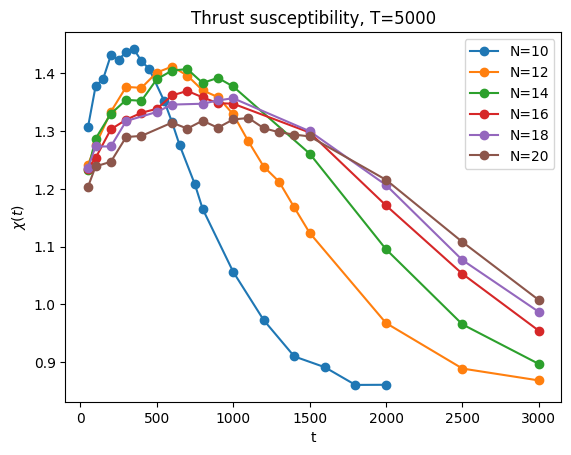

In [32]:
plt.plot(ts_forward_10,chis_thrust_10,'o-',label='N=10')
plt.plot(ts_forward_12,chis_thrust_12,'o-',label='N=12')
plt.plot(ts_forward_14,chis_thrust_14,'o-',label='N=14')
plt.plot(ts_forward_16,chis_thrust_16,'o-',label='N=16')
plt.plot(ts_forward_18,chis_thrust_18,'o-',label='N=18')
plt.plot(ts_forward_20,chis_thrust_20,'o-',label='N=20')
plt.title('Thrust susceptibility, T=5000')
plt.xlabel('t')
plt.ylabel(r'$\chi(t)$')
plt.legend(loc='upper right')

# is thrust axis the latent variable at the top of the tree?

In [33]:
Ntraj=phats_10[0].shape[0]
Nsample=phats_10[0].shape[1]
axes_orig_10 = compute_thrust_axis_torch(ThreeVecToFourVec(pspace_dat_10[None,:Nsample]))
mean_axes_sim_10 = []
for i in range(len(ts_forward_10)):
    axes_denoised=compute_thrust_axis_torch(ThreeVecToFourVec(phats_10[i]))
    mean_axes_sim_10.append(np.mean((np.einsum('tsi,tsi->ts',axes_orig_10,axes_denoised)**2)))

Ntraj=phats_12[0].shape[0]
Nsample=phats_12[0].shape[1]
axes_orig_12 = compute_thrust_axis_torch(ThreeVecToFourVec(pspace_dat_12[None,:Nsample]))
mean_axes_sim_12 = []
for i in range(len(ts_forward_12)):
    axes_denoised=compute_thrust_axis_torch(ThreeVecToFourVec(phats_12[i]))
    mean_axes_sim_12.append(np.mean((np.einsum('tsi,tsi->ts',axes_orig_12,axes_denoised)**2)))

Ntraj=phats_14[0].shape[0]
Nsample=phats_14[0].shape[1]
axes_orig_14 = compute_thrust_axis_torch(ThreeVecToFourVec(pspace_dat_14[None,:Nsample]))
mean_axes_sim_14 = []
for i in range(len(ts_forward_14)):
    axes_denoised=compute_thrust_axis_torch(ThreeVecToFourVec(phats_14[i]))
    mean_axes_sim_14.append(np.mean((np.einsum('tsi,tsi->ts',axes_orig_14,axes_denoised)**2)))

Ntraj=phats_16[0].shape[0]
Nsample=phats_16[0].shape[1]
axes_orig_16 = compute_thrust_axis_torch(ThreeVecToFourVec(pspace_dat_16[None,:Nsample]))
mean_axes_sim_16 = []
for i in range(len(ts_forward_16)):
    axes_denoised=compute_thrust_axis_torch(ThreeVecToFourVec(phats_16[i]))
    mean_axes_sim_16.append(np.mean((np.einsum('tsi,tsi->ts',axes_orig_16,axes_denoised)**2)))

Ntraj=phats_18[0].shape[0]
Nsample=phats_18[0].shape[1]
axes_orig_18 = compute_thrust_axis_torch(ThreeVecToFourVec(pspace_dat_18[None,:Nsample]))
mean_axes_sim_18 = []
for i in range(len(ts_forward_18)):
    axes_denoised=compute_thrust_axis_torch(ThreeVecToFourVec(phats_18[i]))
    mean_axes_sim_18.append(np.mean((np.einsum('tsi,tsi->ts',axes_orig_18,axes_denoised)**2)))

Ntraj=phats_20[0].shape[0]
Nsample=phats_20[0].shape[1]
axes_orig_20 = compute_thrust_axis_torch(ThreeVecToFourVec(pspace_dat_20[None,:Nsample]))
mean_axes_sim_20 = []
for i in range(len(ts_forward_20)):
    axes_denoised=compute_thrust_axis_torch(ThreeVecToFourVec(phats_20[i]))
    mean_axes_sim_20.append(np.mean((np.einsum('tsi,tsi->ts',axes_orig_20,axes_denoised)**2)))

/tmp/ipykernel_2180484/1243953163.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


In [34]:
print(ts_forward_10[np.argmax(chis_thrust_10)])
print(ts_forward_12[np.argmax(chis_thrust_12)])
print(ts_forward_14[np.argmax(chis_thrust_14)])
print(ts_forward_16[np.argmax(chis_thrust_16)])
print(ts_forward_18[np.argmax(chis_thrust_18)])
print(ts_forward_20[np.argmax(chis_thrust_20)])

350
600
700
700
1000
1100


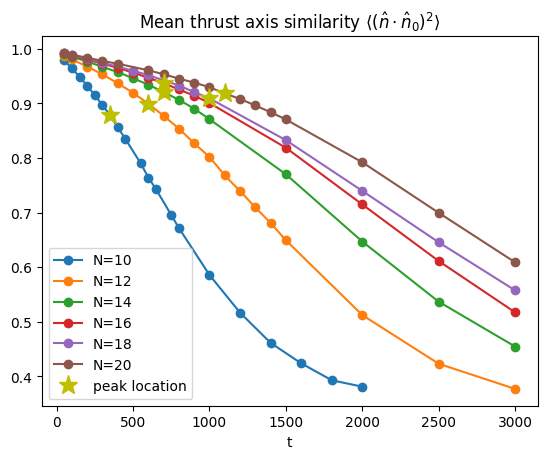

In [35]:
plt.plot(ts_forward_10,mean_axes_sim_10,'o-',label='N=10')
plt.plot(ts_forward_12,mean_axes_sim_12,'o-',label='N=12')
plt.plot(ts_forward_14,mean_axes_sim_14,'o-',label='N=14')
plt.plot(ts_forward_16,mean_axes_sim_16,'o-',label='N=16')
plt.plot(ts_forward_18,mean_axes_sim_18,'o-',label='N=18')
plt.plot(ts_forward_20,mean_axes_sim_20,'o-',label='N=20')

plt.plot(ts_forward_10[np.argmax(chis_thrust_10)],mean_axes_sim_10[np.argmax(chis_thrust_10)],'y*',markersize=14,label='peak location')
plt.plot(ts_forward_12[np.argmax(chis_thrust_12)],mean_axes_sim_12[np.argmax(chis_thrust_12)],'y*',markersize=14)
plt.plot(ts_forward_14[np.argmax(chis_thrust_14)],mean_axes_sim_14[np.argmax(chis_thrust_14)],'y*',markersize=14)
plt.plot(ts_forward_16[np.argmax(chis_thrust_16)],mean_axes_sim_16[np.argmax(chis_thrust_16)],'y*',markersize=14)
plt.plot(ts_forward_18[np.argmax(chis_thrust_18)],mean_axes_sim_18[np.argmax(chis_thrust_18)],'y*',markersize=14)
plt.plot(ts_forward_20[np.argmax(chis_thrust_20)],mean_axes_sim_20[np.argmax(chis_thrust_20)],'y*',markersize=14)
plt.title(r'Mean thrust axis similarity $\langle (\hat{n} \cdot \hat{n}_0)^2 \rangle$')
plt.xlabel('t')
plt.legend(loc='lower left')

# GRAVEYARD

## try EFP susceptibility

first just vanilla EFPs: the fully-correlated ones will just give $\Delta {\rm EFP} = 0$ and cancel out of the susceptibility, so we don't have to remove these by hand

In [60]:
def compute_efp_susceptibility_standard(p0,phat,dmax=5,norm=True): #computes at fixed time: phats is a (Ntraj,Nsample,Nparticles,3) array
    Ntraj=phat.shape[0]
    Nsample=phat.shape[1]
    Nparticles=phat.shape[2]
    efpset = EFPSet(('d<=', dmax), measure='ee', beta=2,coords='epxpypz')
    n_EFP=int(efpset.count())
    efp_vals_p=torch.Tensor(efpset.batch_compute(ThreeVecToFourVec(p0[:Nsample]))) # (Nsample,n_EFP)
    efp_vals_phat=torch.Tensor(efpset.batch_compute(ThreeVecToFourVec(phat.reshape((Ntraj*Nsample,Nparticles,3))))).reshape((Ntraj,Nsample,n_EFP))
    DeltaEFPs = torch.abs(efp_vals_p[None,...]-efp_vals_phat)
    Cij_trajavg=(1/DeltaEFPs.shape[0])*torch.einsum('tnp,tnq->npq',DeltaEFPs,DeltaEFPs)- torch.einsum('np,nq->npq',DeltaEFPs.mean(dim=0),DeltaEFPs.mean(dim=0))
    Cij=Cij_trajavg.mean(dim=0)
    if norm:
        chi=torch.sum(Cij)/torch.sum(Cij.diag())
    else:
        chi=torch.sum(Cij)
    return chi

In [61]:
chis_EFP=[]
for i in range(len(ts_forward)):
    print('computing for t=',ts_forward[i])
    chi = compute_efp_susceptibility_standard(pspace_dat,phats[i],dmax=5)
    chis_EFP.append(chi)

computing for t= 50


/tmp/ipykernel_1969402/3930416006.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


computing for t= 100
computing for t= 150
computing for t= 200
computing for t= 250
computing for t= 350
computing for t= 400
computing for t= 450
computing for t= 550
computing for t= 600
computing for t= 650
computing for t= 750
computing for t= 800
computing for t= 1000
computing for t= 1200
computing for t= 1400
computing for t= 1600
computing for t= 1800
computing for t= 2000


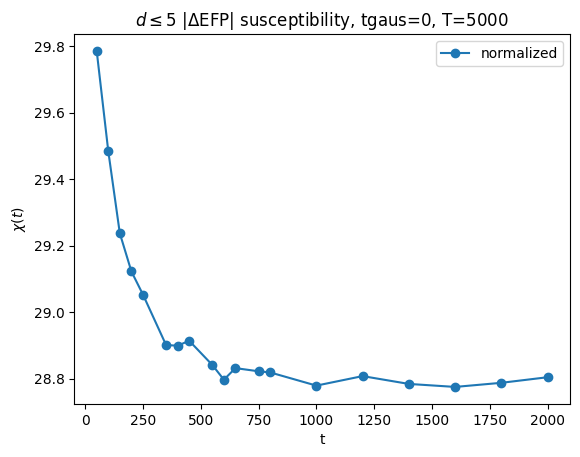

In [64]:
plt.plot(ts_forward,chis_EFP,'o-',label='normalized')
plt.title(r'$d \leq 5$ $|\Delta {\rm EFP}|$ susceptibility, tgaus=0, T=5000')
plt.xlabel('t')
plt.ylabel(r'$\chi(t)$')
plt.legend(loc='upper right')

## now with chromatic number EFPs which are less highly correlated (DOES NOT WORK YET)

In [6]:
def _compute_z_theta_t(events):
    E = events[..., 0]
    p3 = events[..., 1:4]
    z = 2.0 * E / E.sum(dim=-1, keepdim=True)
    pmag = torch.linalg.norm(p3, dim=-1)
    pdot = torch.einsum('...ia,...ja->...ij', p3, p3)
    denom = pmag.unsqueeze(-1) * pmag.unsqueeze(-2)
    cos_th = torch.where(denom > 0, pdot / denom.clamp_min(1e-30),
                         torch.zeros_like(pdot))
    N = events.shape[-2]
    eye = torch.eye(N, dtype=cos_th.dtype, device=cos_th.device).expand_as(cos_th)
    cos_th = torch.where(eye.bool(), torch.ones_like(cos_th), cos_th)
    return z/2, 2*(1.0 - cos_th)

def complete_efp_batch(z,th, k):
    """EFP of the complete graph K_k (chromatic number k) from _compute_z_theta_t output.

             z  : (..., N)     energy fractions E_i/ΣE
             th : (..., N, N)   per-edge kernel 2*(1 - cosθ_ij)  (β=2 ee measure)
    k    : clique size = chromatic number (2 → single edge, 3 → triangle, 4 → K4, …)

    Returns batched EFP values with shape = the leading (...) batch dims of z.
    """
    L = 'ijklmnpqrstu'[:k] #will work up to chromatic number 12
    nodes = ['...' + c for c in L]
    edges = ['...' + L[a] + L[b] for a, b in combinations(range(k), 2)]
    eq = ','.join(nodes + edges) + '->...'
    return torch.einsum(eq, *([z] * k + [th] * len(edges)))

def compute_complete_EFPs_from_3vecs(p3s,kmax): #shape (Nevents, Nparticles, 3)
    p4s = torch.Tensor(ThreeVecToFourVec(p3s))
    z, th = _compute_z_theta_t(p4s)
    EFPvals = torch.zeros((p4s.shape[0],kmax-2))
    for k in range(3,kmax+1):
        EFPvals[:,k-3]=complete_efp_batch(z,th,k)
    return EFPvals

In [28]:
#check that this function gives the same as the triangle EFP
efpgraph_3 = [(0,1), (0,2), (1,2)]
efpgraph_4   = [(0,1), (1,2), (2,3), (3,0),(0,2),(1,3)]
EFP_3 = EFP(efpgraph_3, measure='ee', beta=2, normed=True, coords='epxpypz')
EFP_4 = EFP(efpgraph_4, measure='ee', beta=2, normed=True, coords='epxpypz')
EFPvals_orig_3=EFP_3.batch_compute(ThreeVecToFourVec(pspace_dat[:10]))
EFPvals_orig_4=EFP_4.batch_compute(ThreeVecToFourVec(pspace_dat[:10]))
print(EFPvals_orig_3)
print(EFPvals_orig_4)

/tmp/ipykernel_3004504/3930416006.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


[0.43371605 0.11189708 0.17305918 0.27526109 0.0219563  1.47424483
 1.1348764  0.74664649 0.51501246 1.02378705]
[8.73656595e-02 5.92489701e-03 9.00895430e-03 2.38239013e-02
 1.52232298e-04 6.03273722e-01 6.86937136e-02 1.90188172e-01
 1.29361941e-01 5.01140989e-01]


In [7]:
compute_complete_EFPs_from_3vecs(pspace_dat[:10],4)

/tmp/ipykernel_1543241/3930416006.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


tensor([[4.3372e-01, 8.7365e-02],
        [1.1189e-01, 5.9246e-03],
        [1.7306e-01, 9.0088e-03],
        [2.7526e-01, 2.3824e-02],
        [2.1955e-02, 1.5220e-04],
        [1.4742e+00, 6.0327e-01],
        [1.1349e+00, 6.8692e-02],
        [7.4665e-01, 1.9019e-01],
        [5.1501e-01, 1.2936e-01],
        [1.0238e+00, 5.0114e-01]])

In [8]:
%timeit compute_complete_EFPs_from_3vecs(pspace_dat[:256],4)

/tmp/ipykernel_1543241/3930416006.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


20.4 ms ± 313 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [48]:
def compute_efp_susceptibility_chromatic(p0,phat,kmax=8,norm=True): #computes at fixed time: phats is a (Ntraj,Nsample,Nparticles,3) array
    Ntraj=phat.shape[0]
    Nsample=phat.shape[1]
    Nparticles=phat.shape[2]
    n_EFP=kmax-2
    efp_vals_p=compute_complete_EFPs_from_3vecs(p0[:Nsample],kmax)
    efp_vals_phat=compute_complete_EFPs_from_3vecs(phat.reshape((Ntraj*Nsample,Nparticles,3)),kmax).reshape((Ntraj,Nsample,n_EFP))
    DeltaEFPs = torch.abs(efp_vals_p[None,...]-efp_vals_phat)
    Cij_trajavg=(1/DeltaEFPs.shape[0])*torch.einsum('tnp,tnq->npq',DeltaEFPs,DeltaEFPs)- torch.einsum('np,nq->npq',DeltaEFPs.mean(dim=0),DeltaEFPs.mean(dim=0))
    Cij=Cij_trajavg.mean(dim=0)
    if norm:
        chi=torch.sum(Cij)/torch.sum(Cij.diag())
    else:
        chi=torch.sum(Cij)
    return chi

In [ ]:
chis_EFP_chromatic=[]
for i in range(len(ts_forward)):
    print('computing for t=',ts_forward[i])
    chi = compute_efp_susceptibility_chromatic(pspace_dat,phats[i],kmax=7)
    chis_EFP_chromatic.append(chi)

computing for t= 50


/tmp/ipykernel_3004504/3930416006.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(p4)


In [16]:
chis_EFP_chromatic

[tensor(1.0018),
 tensor(1.0001),
 tensor(1.0111),
 tensor(1.0029),
 tensor(1.0022),
 tensor(1.0259),
 tensor(1.0100),
 tensor(1.0118)]